In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("global_pharmacy_sales_2020_2025_daily_dataset.csv")

print(df.shape)
print(df.head())

(177990, 14)
         date  year  month  day         region    country category  \
0  2025-10-12  2025     10   12    Middle East        UAE  Chronic   
1  2020-09-15  2020      9   15     South Asia      India  Chronic   
2  2020-02-26  2020      2   26    Middle East        UAE  Vitamin   
3  2025-11-09  2025     11    9     South Asia  Sri Lanka  Chronic   
4  2022-04-04  2022      4    4  South America  Argentina  Chronic   

     medicine age_group  units_sold  unit_price  stock_level  \
0  Amlodipine      0-12         328       45.38         4774   
1  Amlodipine     26-45         371       75.49         4584   
2   Vitamin C      0-12         948       22.51         3934   
3  Amlodipine      0-12         275       63.29         4544   
4  Amlodipine     26-45         563       44.28         4284   

   expiry_days_remaining  covid_flag  
0                    466           0  
1                    181           1  
2                    556           1  
3                    330 

In [4]:
# Select numerical columns

cols = [
    'year',
    'month',
    'day',
    'units_sold',
    'unit_price',
    'stock_level',
    'expiry_days_remaining',
    'covid_flag'
]

x = df[cols]

In [5]:
# PCA is sensitive to different scales so we need to apply stander scaler to reduce the variation
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_sc = sc.fit_transform(x)

In [6]:
#apply the pca it create new component
pc = PCA()
x_pc = pc.fit_transform(x_sc)

In [8]:
# check variance ratio it show the much information each component keeps.
evr = pc.explained_variance_ratio_
print(evr)

[0.31186172 0.17859904 0.12559164 0.12505571 0.12439096 0.10548165
 0.02121437 0.0078049 ]


In [9]:
#calculate cumulative variance it use to decide howm many component to keeps, it add the variance of all components 
cv = np.cumsum(evr)
print(cv)

[0.31186172 0.49046077 0.61605241 0.74110811 0.86549907 0.97098072
 0.9921951  1.        ]


In [10]:
#We select enough components to retain 95% of the data information.
#This reduces dimensions while keeping important patterns.
n = np.argmax(cv >= 0.95) + 1
print("optimal components:", n)

Optimal Components: 6


In [12]:
# apply pca again with optimal components

pc = PCA(n_components=n)

x_new = pc.fit_transform(x_sc)

print("Original Shape :", x_sc.shape)
print("Reduced Shape :", x_new.shape)

Original Shape : (177990, 8)
Reduced Shape : (177990, 6)


In [19]:
load = pd.DataFrame(pc.components_.T)

print(load)

          0         1         2         3         4         5
0 -0.436794  0.537690  0.010537 -0.004227  0.012567  0.182345
1 -0.175217 -0.424492  0.032096 -0.009374  0.022008  0.887253
2 -0.003339 -0.014679  0.715879  0.189864  0.670015 -0.048183
3  0.533731  0.368127  0.017087 -0.005537  0.014857  0.274558
4  0.001849 -0.002303 -0.696934  0.200172  0.688560  0.009505
5 -0.529918 -0.372539 -0.016550  0.004675 -0.014012 -0.286863
6  0.000636  0.007359  0.004302  0.961100 -0.275308  0.020468
7  0.461316 -0.506081 -0.008645  0.003461 -0.010556 -0.137945


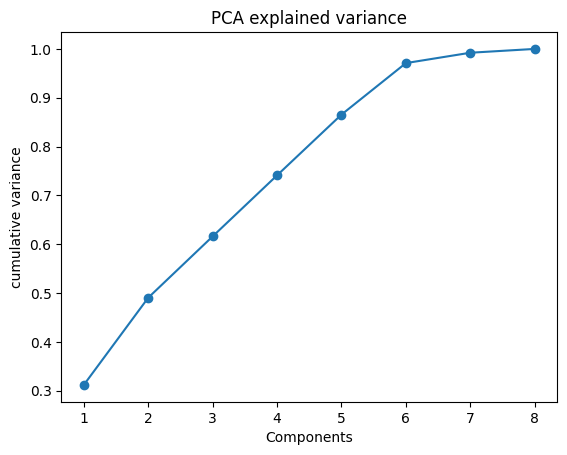

In [21]:
plt.plot(range(1, len(cv)+1), cv, marker='o',color="")

plt.xlabel("Components")
plt.ylabel("cumulative variance")
plt.title("PCA explained variance")

plt.show()